# Visualización de la Afluencia del Metro de la Ciudad de México

## 1. Exploración del dataframe

In [1]:
# Importando librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Dataframe de 2010 a septiembre 2025
url = 'https://github.com/AndrsGzRo/prediccion-afluencia-metrocdmx/raw/main/Afluencia_Diaria_MetroCDMX.zip'
df_raw = pd.read_csv(url,compression='zip')
df_raw.head()

,fecha,anio,mes,linea,estacion,afluencia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227
1,2010-01-01,2010,Enero,Linea 1,Isabel la CatÃ³lica,6487
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304
3,2010-01-01,2010,Enero,Linea 1,Pino SuÃ¡rez,8679
4,2010-01-01,2010,Enero,Linea 1,GÃ³mez FarÃ­as,19499


### 1.1 Información sobre el dataframe

In [3]:
def info_df(df):
    print('---------Información general del Dataframe---------')
    print(df.info())
    print('---------Estadísticas del df---------')
    print(df.describe())
    print('---------Valores nulos---------')
    print(df.isnull().sum().sort_values(ascending=False))
    print('---------Valores únicos---------')
    print(df.nunique())

info_df(df_raw)


---------Información general del Dataframe---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1121640 entries, 0 to 1121639
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   fecha      1121640 non-null  object
 1   anio       1121640 non-null  int64 
 2   mes        1121640 non-null  object
 3   linea      1121640 non-null  object
 4   estacion   1121640 non-null  object
 5   afluencia  1121640 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 51.3+ MB
None
---------Estadísticas del df---------
               anio     afluencia
count  1.121640e+06  1.121640e+06
mean   2.017380e+03  1.969899e+04
std    4.547000e+00  1.947216e+04
min    2.010000e+03  0.000000e+00
25%    2.013000e+03  7.435000e+03
50%    2.017000e+03  1.445200e+04
75%    2.021000e+03  2.551000e+04
max    2.025000e+03  2.630560e+05
---------Valores nulos---------
fecha        0
anio         0
mes          0
linea        0
estacion     0
a

### 1.2 Convertir a ```datetime```

In [4]:
df = df_raw.copy()
df['fecha'] = pd.to_datetime(df['fecha'],errors='coerce')
df['fecha'].dtype

dtype('<M8[ns]')

### 1.3 Mes a número

In [5]:
meses = {
    'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,'Mayo':5,'Junio':6,'Julio':7,
    'Agosto':8,'Septiembre':9,'Octubre':10,'Noviembre':11,'Diciembre':12}

df['mes_num'] = df['mes'].map(meses)

### 1.4 Obtener día de la fecha

In [6]:
df['día'] = df['fecha'].dt.day
df['día_semana'] = df['fecha'].dt.day_name()
df['día_semana'] = df['día_semana'].replace({
    'Monday':'Lunes', 'Tuesday':'Martes', 'Wednesday':'Miércoles',
    'Thursday':'Jueves','Friday':'Viernes','Saturday':'Sábado',
    'Sunday':'Domingo'
})
df.head()

,fecha,anio,mes,linea,estacion,afluencia,mes_num,día,día_semana
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227,1,1,Viernes
1,2010-01-01,2010,Enero,Linea 1,Isabel la CatÃ³lica,6487,1,1,Viernes
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304,1,1,Viernes
3,2010-01-01,2010,Enero,Linea 1,Pino SuÃ¡rez,8679,1,1,Viernes
4,2010-01-01,2010,Enero,Linea 1,GÃ³mez FarÃ­as,19499,1,1,Viernes


### 1.5 Correción de nombre de las estaciones

In [7]:
df['estacion'] = df['estacion'].replace({
    'Isabel la CatÃ³lica':'Isabel la Católica', 'Pino SuÃ¡rez':'Pino Suárez',
    'GÃ³mez FarÃ\xadas':'Gómez Farías','La Villa/BasÃ\xadlica':'La Villa-Basílica',
    'PantitlÃ¡n':'Pantitlán','VelÃ³dromo':'Velódromo','RefinerÃ\xada':'Refinería',
    'EtiopÃ\xada/Plaza de la Transparencia':'Etiopía/ Plaza de la Transparencia',
    'DivisiÃ³n del Norte':'División del Norte',
    'FerrerÃ\xada/Arena Ciudad de MÃ©xico':'Ferretería/Arena Ciudad de México',
    'Instituto del PetrÃ³leo':'Instituto del Petróleo','San Juan de LetrÃ¡n':'San Juan Letrán',
    'OceanÃ\xada':'Ocenía','NezahualcÃ³yotl':'Nezahualcóyotl','RevoluciÃ³n':'Revolución',
    'JuÃ¡rez':'Juárez','OlÃ\xadmpica':'Olímpica','CulhuacÃ¡n':'Culhuacán',
    'PeÃ±Ã³n Viejo':'Peñón Viejo','San AndrÃ©s TomatlÃ¡n':'San Andrés Tomatlán',
    'AragÃ³n':'Aragón','MartÃ\xadn Carrera':'Martín Carrera','Aquiles SerdÃ¡n':'Aquiles Serdán',
    'San JoaquÃ\xadn':'San Joaquín','TezozÃ³moc':'Tezozómoc','CuitlÃ¡huac':'Cuitláhuac',
    'Terminal AÃ©rea':'Terminal Aérea','Centro MÃ©dico':'Centro Médico','CoyoacÃ¡n':'Coyoacán',
    'ZÃ³calo/Tenochtitlan':'Zócalo/Tenochtitlan','Boulevard Puerto AÃ©reo':'Boulevard Puerto Aéreo',
    'Villa de CortÃ©s':'Villa de Cortés','TalismÃ¡n':'Talismán','Valle GÃ³mez':'Valle Gómez',
    'PolitÃ©cnico':'Politécnico','NiÃ±os HÃ©roes':'Niños Héroes','TasqueÃ±a':'Tasqueña',
    'JuanacatlÃ¡n':'Juanacatlán','Plaza AragÃ³n':'Plaza Aragón','ZapotitlÃ¡n':'Zapotitlán',
    'RÃ\xado de los Remedios':'Río de los Remedios','MÃºzquiz':'Múzquiz',
    'EscuadrÃ³n 201':'Escuadrón 201','PerifÃ©rico Oriente':'Periférico Oriente',
    'TlÃ¡huac':'Tláhuac','San LÃ¡zaro':'San Lázaro','Villa de AragÃ³n':'Villa de Aragón',
    'AgrÃ\xadcola Oriental':'Agrícola Oriental','Deportivo OceanÃ\xada':'Deportivo Oceanía',
    'Bosque de AragÃ³n':'Bosque de Aragón','ConstituciÃ³n de 1917':'Constitución de 1917',
    'CuauhtÃ©moc':'Cuauhtémoc','Ricardo Flores MagÃ³n':'Ricardo Flores Magón',
    'LÃ¡zaro CÃ¡rdenas':'Lázaro Cárdenas','GÃ³mez Farias':'Gómez Farías',
    'PeÃ±Ã³n viejo':'Peñón Viejo','Miguel Ã\x81ngel de Quevedo':'Miguel Ángel de Quevedo'
})


### 1.6 Correción de Líneas

In [8]:
df['linea'].unique()

array(['Linea 1', 'Linea 6', 'Linea 9', 'Linea 8', 'Linea 5', 'Linea 7',
       'Linea 3', 'Linea 4', 'Linea 2', 'Linea B', 'Linea 12', 'Linea A',
       'LÃ\xadnea 1', 'LÃ\xadnea 12', 'LÃ\xadnea 2', 'LÃ\xadnea 3',
       'LÃ\xadnea 4', 'LÃ\xadnea 5', 'LÃ\xadnea 6', 'LÃ\xadnea 7',
       'LÃ\xadnea 8', 'LÃ\xadnea 9', 'LÃ\xadnea A', 'LÃ\xadnea B'],
      dtype=object)

In [9]:
df['linea'] = df['linea'].replace({
    'LÃ\xadnea 1': 'Línea 1','LÃ\xadnea 2': 'Línea 2','LÃ\xadnea 3': 'Línea 3',
    'LÃ\xadnea 4': 'Línea 4','LÃ\xadnea 5': 'Línea 5','LÃ\xadnea 6': 'Línea 6',
    'LÃ\xadnea 7': 'Línea 7','LÃ\xadnea 8': 'Línea 8','LÃ\xadnea 9': 'Línea 9',
    'LÃ\xadnea 12': 'Línea 12','LÃ\xadnea A': 'Línea A','LÃ\xadnea B': 'Línea B',
    'Linea 1':'Línea 1', 'Linea 6':'Línea 6','Linea 9':'Línea 9','Linea 8':'Línea 8',
    'Linea 5':'Línea 5','Linea 7':'Línea 7','Linea 3':'Línea 3','Linea 4':'Línea 4',
    'Linea 2':'Línea 2','Linea B':'Línea B','Linea 12':'Línea 12','Linea A':'Línea A'
})
df_hist = df
df_hist.head()

,fecha,anio,mes,linea,estacion,afluencia,mes_num,día,día_semana
0,2010-01-01,2010,Enero,Línea 1,Zaragoza,20227,1,1,Viernes
1,2010-01-01,2010,Enero,Línea 1,Isabel la Católica,6487,1,1,Viernes
2,2010-01-01,2010,Enero,Línea 1,Moctezuma,10304,1,1,Viernes
3,2010-01-01,2010,Enero,Línea 1,Pino Suárez,8679,1,1,Viernes
4,2010-01-01,2010,Enero,Línea 1,Gómez Farías,19499,1,1,Viernes


## 2. Afluencia de Octubre a Diciembre 2025

In [10]:
url = 'https://raw.githubusercontent.com/AndrsGzRo/prediccion-afluencia-metrocdmx/refs/heads/main/data-2026-01-28.csv'
df_nuevo = pd.read_csv(url)
df_nuevo = df_nuevo.copy()
df_nuevo.head()

,fecha,mes,anio,linea,estacion,tipo_pago,afluencia,temporal_fecha,..anio_fecha
0,2025-10-01,Octubre,2025,Linea 1,PantitlÃ¡n,Boleto,0,2025-10,2025
1,2025-10-01,Octubre,2025,Linea 1,PantitlÃ¡n,Prepago,33468,2025-10,2025
2,2025-10-01,Octubre,2025,Linea 1,PantitlÃ¡n,Gratuidad,5673,2025-10,2025
3,2025-10-01,Octubre,2025,Linea 1,Zaragoza,Boleto,0,2025-10,2025
4,2025-10-01,Octubre,2025,Linea 1,Zaragoza,Prepago,21151,2025-10,2025


In [11]:
df_nuevo = df_nuevo.drop(columns=['temporal_fecha','..anio_fecha'])
df_nuevo.head()

,fecha,mes,anio,linea,estacion,tipo_pago,afluencia
0,2025-10-01,Octubre,2025,Linea 1,PantitlÃ¡n,Boleto,0
1,2025-10-01,Octubre,2025,Linea 1,PantitlÃ¡n,Prepago,33468
2,2025-10-01,Octubre,2025,Linea 1,PantitlÃ¡n,Gratuidad,5673
3,2025-10-01,Octubre,2025,Linea 1,Zaragoza,Boleto,0
4,2025-10-01,Octubre,2025,Linea 1,Zaragoza,Prepago,21151


### 2.1 Asegurando fechas

In [12]:
df_nuevo['fecha'] = pd.to_datetime(df_nuevo['fecha'])
df_nuevo['anio'] = df_nuevo['anio'].astype(int)
df_nuevo['mes_num'] = df_nuevo['mes'].map(meses)
df_nuevo['día'] = df_nuevo['fecha'].dt.day
df_nuevo['día_semana'] = df_nuevo['fecha'].dt.day_name()
df_nuevo['día_semana'] = df_nuevo['día_semana'].replace({
    'Monday':'Lunes', 'Tuesday':'Martes', 'Wednesday':'Miércoles',
    'Thursday':'Jueves','Friday':'Viernes','Saturday':'Sábado',
    'Sunday':'Domingo'
})
df_nuevo.head()

,fecha,mes,anio,linea,estacion,tipo_pago,afluencia,mes_num,día,día_semana
0,2025-10-01,Octubre,2025,Linea 1,PantitlÃ¡n,Boleto,0,10,1,Miércoles
1,2025-10-01,Octubre,2025,Linea 1,PantitlÃ¡n,Prepago,33468,10,1,Miércoles
2,2025-10-01,Octubre,2025,Linea 1,PantitlÃ¡n,Gratuidad,5673,10,1,Miércoles
3,2025-10-01,Octubre,2025,Linea 1,Zaragoza,Boleto,0,10,1,Miércoles
4,2025-10-01,Octubre,2025,Linea 1,Zaragoza,Prepago,21151,10,1,Miércoles


### 2.2 Nombre de estaciones

In [13]:
df_nuevo['estacion'] = df_nuevo['estacion'].replace({
    'Isabel la CatÃ³lica':'Isabel la Católica', 'Pino SuÃ¡rez':'Pino Suárez',
    'GÃ³mez FarÃ\xadas':'Gómez Farías','La Villa/BasÃ\xadlica':'La Villa-Basílica',
    'PantitlÃ¡n':'Pantitlán','VelÃ³dromo':'Velódromo','RefinerÃ\xada':'Refinería',
    'EtiopÃ\xada/Plaza de la Transparencia':'Etiopía/ Plaza de la Transparencia',
    'DivisiÃ³n del Norte':'División del Norte',
    'FerrerÃ\xada/Arena Ciudad de MÃ©xico':'Ferretería/Arena Ciudad de México',
    'Instituto del PetrÃ³leo':'Instituto del Petróleo','San Juan de LetrÃ¡n':'San Juan Letrán',
    'OceanÃ\xada':'Ocenía','NezahualcÃ³yotl':'Nezahualcóyotl','RevoluciÃ³n':'Revolución',
    'JuÃ¡rez':'Juárez','OlÃ\xadmpica':'Olímpica','CulhuacÃ¡n':'Culhuacán',
    'PeÃ±Ã³n Viejo':'Peñón Viejo','San AndrÃ©s TomatlÃ¡n':'San Andrés Tomatlán',
    'AragÃ³n':'Aragón','MartÃ\xadn Carrera':'Martín Carrera','Aquiles SerdÃ¡n':'Aquiles Serdán',
    'San JoaquÃ\xadn':'San Joaquín','TezozÃ³moc':'Tezozómoc','CuitlÃ¡huac':'Cuitláhuac',
    'Terminal AÃ©rea':'Terminal Aérea','Centro MÃ©dico':'Centro Médico','CoyoacÃ¡n':'Coyoacán',
    'ZÃ³calo/Tenochtitlan':'Zócalo/Tenochtitlan','Boulevard Puerto AÃ©reo':'Boulevard Puerto Aéreo',
    'Villa de CortÃ©s':'Villa de Cortés','TalismÃ¡n':'Talismán','Valle GÃ³mez':'Valle Gómez',
    'PolitÃ©cnico':'Politécnico','NiÃ±os HÃ©roes':'Niños Héroes','TasqueÃ±a':'Tasqueña',
    'JuanacatlÃ¡n':'Juanacatlán','Plaza AragÃ³n':'Plaza Aragón','ZapotitlÃ¡n':'Zapotitlán',
    'RÃ\xado de los Remedios':'Río de los Remedios','MÃºzquiz':'Múzquiz',
    'EscuadrÃ³n 201':'Escuadrón 201','PerifÃ©rico Oriente':'Periférico Oriente',
    'TlÃ¡huac':'Tláhuac','San LÃ¡zaro':'San Lázaro','Villa de AragÃ³n':'Villa de Aragón',
    'AgrÃ\xadcola Oriental':'Agrícola Oriental','Deportivo OceanÃ\xada':'Deportivo Oceanía',
    'Bosque de AragÃ³n':'Bosque de Aragón','ConstituciÃ³n de 1917':'Constitución de 1917',
    'CuauhtÃ©moc':'Cuauhtémoc','Ricardo Flores MagÃ³n':'Ricardo Flores Magón',
    'LÃ¡zaro CÃ¡rdenas':'Lázaro Cárdenas','GÃ³mez Farias':'Gómez Farías',
    'PeÃ±Ã³n viejo':'Peñón Viejo','Miguel Ã\x81ngel de Quevedo':'Miguel Ángel de Quevedo'
})

### 2.3 Nombre de Líneas

In [14]:
df_nuevo['linea'] = df_nuevo['linea'].replace({
    'LÃ\xadnea 1': 'Línea 1','LÃ\xadnea 2': 'Línea 2','LÃ\xadnea 3': 'Línea 3',
    'LÃ\xadnea 4': 'Línea 4','LÃ\xadnea 5': 'Línea 5','LÃ\xadnea 6': 'Línea 6',
    'LÃ\xadnea 7': 'Línea 7','LÃ\xadnea 8': 'Línea 8','LÃ\xadnea 9': 'Línea 9',
    'LÃ\xadnea 12': 'Línea 12','LÃ\xadnea A': 'Línea A','LÃ\xadnea B': 'Línea B',
    'Linea 1':'Línea 1', 'Linea 6':'Línea 6','Linea 9':'Línea 9','Linea 8':'Línea 8',
    'Linea 5':'Línea 5','Linea 7':'Línea 7','Linea 3':'Línea 3','Linea 4':'Línea 4',
    'Linea 2':'Línea 2','Linea B':'Línea B','Linea 12':'Línea 12','Linea A':'Línea A'
})
df_nuevo.head()

,fecha,mes,anio,linea,estacion,tipo_pago,afluencia,mes_num,día,día_semana
0,2025-10-01,Octubre,2025,Línea 1,Pantitlán,Boleto,0,10,1,Miércoles
1,2025-10-01,Octubre,2025,Línea 1,Pantitlán,Prepago,33468,10,1,Miércoles
2,2025-10-01,Octubre,2025,Línea 1,Pantitlán,Gratuidad,5673,10,1,Miércoles
3,2025-10-01,Octubre,2025,Línea 1,Zaragoza,Boleto,0,10,1,Miércoles
4,2025-10-01,Octubre,2025,Línea 1,Zaragoza,Prepago,21151,10,1,Miércoles


### 2.4 Afluencia total por estación y día

In [15]:
df_nuevo_total = (
    df_nuevo
    .groupby(['fecha','anio','linea','mes','estacion','mes_num','día','día_semana'],
             as_index=False)
    ['afluencia'].sum()
)
df_nuevo_total.head()

,fecha,anio,linea,mes,estacion,mes_num,día,día_semana,afluencia
0,2025-10-01,2025,Línea 1,Octubre,Balbuena,10,1,Miércoles,8667
1,2025-10-01,2025,Línea 1,Octubre,Balderas,10,1,Miércoles,18732
2,2025-10-01,2025,Línea 1,Octubre,Boulevard Puerto Aéreo,10,1,Miércoles,18047
3,2025-10-01,2025,Línea 1,Octubre,Candelaria,10,1,Miércoles,16963
4,2025-10-01,2025,Línea 1,Octubre,Chapultepec,10,1,Miércoles,48884


## 3. Concat de ```df_hist``` y ```df_nuevo_total```

In [16]:
df_full = pd.concat(
    [df_hist,df_nuevo_total],
    ignore_index=True
)
df_full = df_full.sort_values(['linea','estacion','fecha']).reset_index(drop=True)
df_full.head()

,fecha,anio,mes,linea,estacion,afluencia,mes_num,día,día_semana
0,2010-01-01,2010,Enero,Línea 1,Balbuena,2879,1,1,Viernes
1,2010-01-02,2010,Enero,Línea 1,Balbuena,7453,1,2,Sábado
2,2010-01-03,2010,Enero,Línea 1,Balbuena,3814,1,3,Domingo
3,2010-01-04,2010,Enero,Línea 1,Balbuena,10356,1,4,Lunes
4,2010-01-05,2010,Enero,Línea 1,Balbuena,10170,1,5,Martes


## 4. Visualización

In [17]:
sns.set_theme(style='darkgrid')
metro_color = '#FE5000'
colores_metro = {
    'Línea 1':'#F04E98',
    'Línea 2':'#005EB8',
    'Línea 3':'#AF9800',
    'Línea 4':'#6BBBAE',
    'Línea 5':'#FFD100',
    'Línea 6':'#DA291C',
    'Línea 7':'#E87722',
    'Línea 8':'#009444',
    'Línea 9':'#512F2E',
    'Línea A':'#981D97',
    'Línea B':'#B1B3B3',
    'Línea 12':'#B0A32A'
}

### 4.1 Evolución de la Afluencia diaria

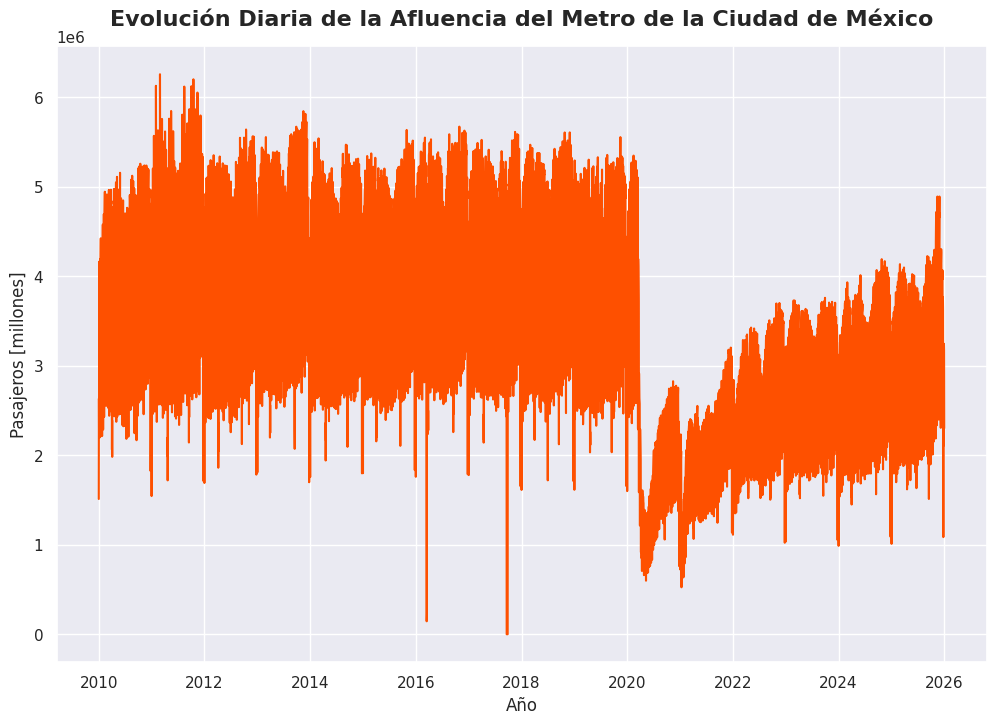

In [18]:
afluencia_diaria = (
    df_full.groupby('fecha')['afluencia'].sum().reset_index(name='Afluencia')
)

plt.figure(figsize=(12,8))
sns.lineplot(
    data=afluencia_diaria,
    x='fecha',
    y='Afluencia',
    color = metro_color
)
plt.xlabel('Año',fontsize=12)
plt.ylabel('Pasajeros [millones]',fontsize=12)
plt.title('Evolución Diaria de la Afluencia del Metro de la Ciudad de México',
          fontsize=16,fontweight='bold',pad=15)
plt.show()

### 4.2 Afluencia en 2025

In [69]:
afluencia_2025 = (
    df_full[df_full['anio'] == 2025].copy()
)
afluencia_2025.head()

,fecha,anio,mes,linea,estacion,afluencia,mes_num,día,día_semana
5479,2025-01-01,2025,Enero,Línea 1,Balbuena,2071,1,1,Miércoles
5480,2025-01-02,2025,Enero,Línea 1,Balbuena,6142,1,2,Jueves
5481,2025-01-03,2025,Enero,Línea 1,Balbuena,6849,1,3,Viernes
5482,2025-01-04,2025,Enero,Línea 1,Balbuena,6202,1,4,Sábado
5483,2025-01-05,2025,Enero,Línea 1,Balbuena,5079,1,5,Domingo


#### 4.2.1 Afluencia Diaria en 2025

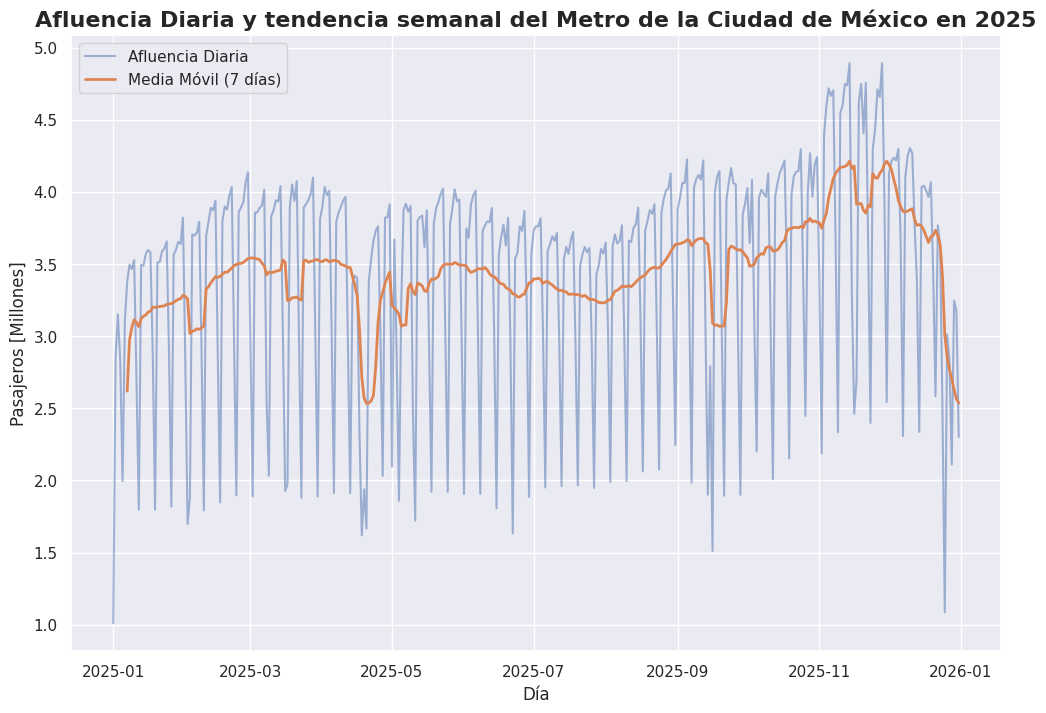

In [93]:
afluencia_diaria_2025 = (
    afluencia_2025
    .groupby('fecha')['afluencia'].sum().reset_index(name='Afluencia_Total')
)
# Afluencia en Millones
afluencia_diaria_2025['Afluencia_Millones'] = afluencia_diaria_2025['Afluencia_Total']/1e6

# Media Móvil 7 días
afluencia_diaria_2025['Afluencia_MM7'] = (
    afluencia_diaria_2025['Afluencia_Millones'].rolling(7).mean()
)

plt.figure(figsize=(12,8))
sns.lineplot(
    data=afluencia_diaria_2025,
    x='fecha',
    y='Afluencia_Millones',
    alpha=0.5,
    label='Afluencia Diaria'
)

sns.lineplot(
    data=afluencia_diaria_2025,
    x='fecha',
    y='Afluencia_MM7',
    linewidth=2,
    label='Media Móvil (7 días)'
)

plt.xlabel('Día')
plt.ylabel('Pasajeros [Millones]')
plt.title('Afluencia Diaria y tendencia semanal del Metro de la Ciudad de México en 2025',
          fontsize=16,
          fontweight='bold')
plt.show()

#### 4.2.2 Afluencia Mensual en 2025

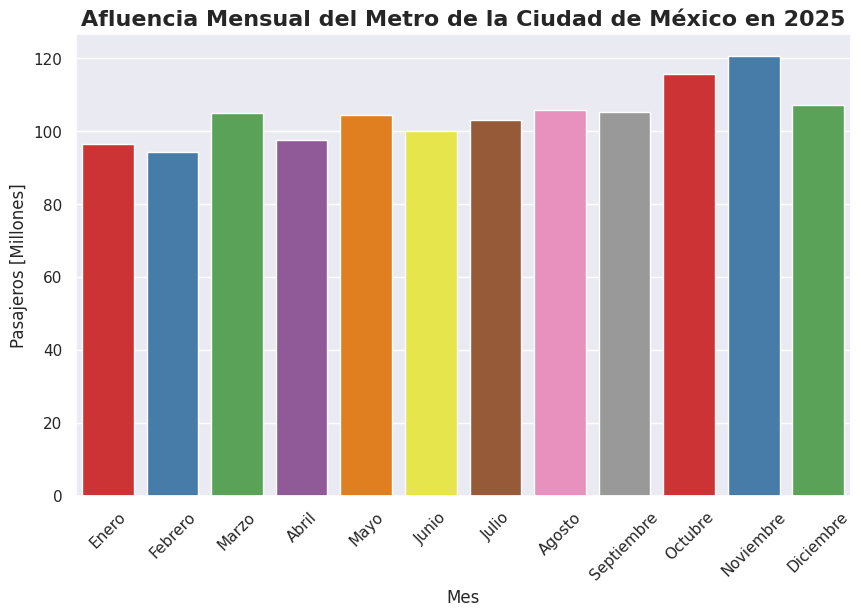

In [96]:
afluencia_mes_2025 = (
    afluencia_2025
    .groupby('mes')['afluencia'].sum().reset_index(name='Afluencia_Total')
)

# Orden de los meses
orden_meses = [
    'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
    'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'
]

afluencia_mes_2025['mes'] = pd.Categorical(
    afluencia_mes_2025['mes'],
    categories=orden_meses,
    ordered=True
)
afluencia_mes_2025 = afluencia_mes_2025.sort_values('mes')

# Millones de pasajeros
afluencia_mes_2025['Afluencia_Millones'] = afluencia_mes_2025['Afluencia_Total'] /1e6
plt.figure(figsize=(10,6))
sns.barplot(
    data=afluencia_mes_2025,
    x='mes',
    y='Afluencia_Millones',
    hue='mes',
    palette='Set1'
)
plt.xlabel('Mes')
plt.ylabel('Pasajeros [Millones]')
plt.title('Afluencia Mensual del Metro de la Ciudad de México en 2025',fontsize=16,
          fontweight='bold')
plt.xticks(rotation=45)
plt.show()